In [19]:
import shapefile
import geopandas as gpd
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from shapely.geometry import shape as shapely_shape

import torch
import networkx as nx
from torch_geometric.utils import to_networkx

import pickle
import tensorflow as tf
from sklearn.model_selection import train_test_split

from scipy.spatial.distance import directed_hausdorff
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
labels_font = {'family': 'serif', 'size': 10} #Times New Roman
tick_font = {'family': 'serif', 'size': 10}
title_font = {'family': 'serif', 'size': 14}
legend_font = {'family': 'serif', 'size': 10}

## LOAD MODELS

In [3]:
# LSTM AE MODEL
lstm_autoencoder = tf.keras.models.load_model('../checkpoints/autoencoder/model/best_32_batches_100_epochs_huber_local_1411_1548.keras')

In [4]:
# LSTM AE MODEL
#loss = siamese_loss_wrapper(0.001)
#siamese_lstm_autoencoder = tf.keras.models.load_model('../checkpoints/siamese/model/1811_1801_pretrained_local_16_batches_50_epochs.keras', custom_objects={'siamese_loss': loss})

In [5]:
# GRAPH SAGE SEQ

In [6]:
# GRAPH SAGE DELAUNAY

## LOAD INPUT DATA

In [7]:
# SIAMESE & AE 
PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_local_original.npy'
PATH_TRAINING_B =  '../data/preprocessing/normalized/normalized_local_close.npy'

PATH_TRAINING_A_CLEAN = '../data/preprocessing/normalized/normalized_local_original.npy'
PATH_TRAINING_B_CLEAN = '../data/preprocessing/normalized/normalized_local_far.npy'

In [87]:
# LSTM AE 
lstm_ae_noisy = np.load(PATH_TRAINING_A)

lstm_ae_train, temp = train_test_split(lstm_ae_noisy, test_size=0.2, random_state=42)  
lstm_ae_val, lstm_ae_test = train_test_split(temp, test_size=0.5, random_state=42) 

print(f'Train Shape {lstm_ae_train.shape}, Val Shape {lstm_ae_val.shape}, Test Shape {lstm_ae_test.shape}')

Train Shape (54822, 64, 2), Val Shape (6853, 64, 2), Test Shape (6853, 64, 2)


In [9]:
#SIAMESE

# Load full arrays
lines_a_noisy = np.load(PATH_TRAINING_A)[:20000]
lines_b_noisy = np.load(PATH_TRAINING_B)[:20000]
lines_a_clean = np.load(PATH_TRAINING_A_CLEAN)[:20000]
lines_b_clean = np.load(PATH_TRAINING_B_CLEAN)[:20000]

# Total number of samples
n_total = lines_a_noisy.shape[0]

# Compute split indices
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

# --- TRAIN ---
train_slice = slice(0, n_train)
lines_a_noisy_train = lines_a_noisy[train_slice]
lines_b_noisy_train = lines_b_noisy[train_slice]
lines_a_clean_train = lines_a_clean[train_slice]
lines_b_clean_train = lines_b_clean[train_slice]

# --- VALIDATION ---
val_slice = slice(n_train, n_train + n_val)
lines_a_noisy_val = lines_a_noisy[val_slice]
lines_b_noisy_val = lines_b_noisy[val_slice]
lines_a_clean_val = lines_a_clean[val_slice]
lines_b_clean_val = lines_b_clean[val_slice]

# --- TEST ---
test_slice = slice(n_train + n_val, n_total)
lines_a_noisy_test = lines_a_noisy[test_slice]
lines_b_noisy_test = lines_b_noisy[test_slice]
lines_a_clean_test = lines_a_clean[test_slice]
lines_b_clean_test = lines_b_clean[test_slice]


print(f'Train: {lines_a_noisy_train.shape}, Val: {lines_a_noisy_val.shape}, Test: {lines_a_noisy_test.shape}')

Train: (14000, 64, 2), Val: (3000, 64, 2), Test: (3000, 64, 2)


In [ ]:
# ORIGINAL
original_interpolated_lines = np.load(f'../data/preprocessing/interpolated/interpolated_lines.npy')

# ROTATION
rotaded_lines=np.load(f'../data/preprocessing/rotated/rotated_lines.npy')

# ADDING SYNTHETIC
rotated_lines_close = np.load(f'../data/preprocessing/rotated/rotated_lines_close.npy')
rotated_lines_far = np.load(f'../data/preprocessing/rotated/rotated_lines_far.npy')

# MIN MAX NORMALIZATION
normalized_original = np.load(f'../data/preprocessing/normalized/normalized_global_original.npy')
normalized_lines_close = np.load(f'../data/preprocessing/normalized/normalized_global_close.npy')
normalized_lines_far = np.load(f'../data/preprocessing/normalized/normalized_global_far.npy')

In [157]:
def plot_input_seq(lines, lines_syn_1=None, lines_syn_2=None, data_range=range(0,1), description=None, saving_img=True):

    for i in data_range:
        
        plt.figure(figsize=(10, 8))
        line = lines[i]
        x, y = line[:, 0], line[:, 1]
        #plt.scatter(x, y, color='#00305D', label='Original Line', s=20)
        plt.plot(x, y, color='#00305D', label=f'Original Line')

        if lines_syn_1 is not None:
            line_s1 = lines_syn_1[i]
            x_s1, y_s1 = line_s1[:, 0], line_s1[:, 1]
            plt.plot(x_s1, y_s1, color='#EC9A29', label=f'Synthetic Original')

        if lines_syn_2 is not None:
            line_s2 = lines_syn_2[i]
            x_s2, y_s2 = line_s2[:, 0], line_s2[:, 1]
            plt.plot(x_s2, y_s2, color='#A8201A', label=f'Synthetic Displaced')

        if description:
            plt.title(f'{description} - Line number {i}', fontdict=title_font)
        else:
            plt.description(f'Line number {i}', fontdict=title_font)
        
        plt.xlabel('X', fontdict=labels_font)
        plt.ylabel('Y', fontdict=labels_font)
        plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
        plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])
        plt.legend(prop=legend_font)

        plt.axis('equal')
        plt.grid(True)

        if saving_img:
            description = description.replace(" ", "_").lower()
            save_path = f'../data/figures/encoding_input_sequences_{description}.png'
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()

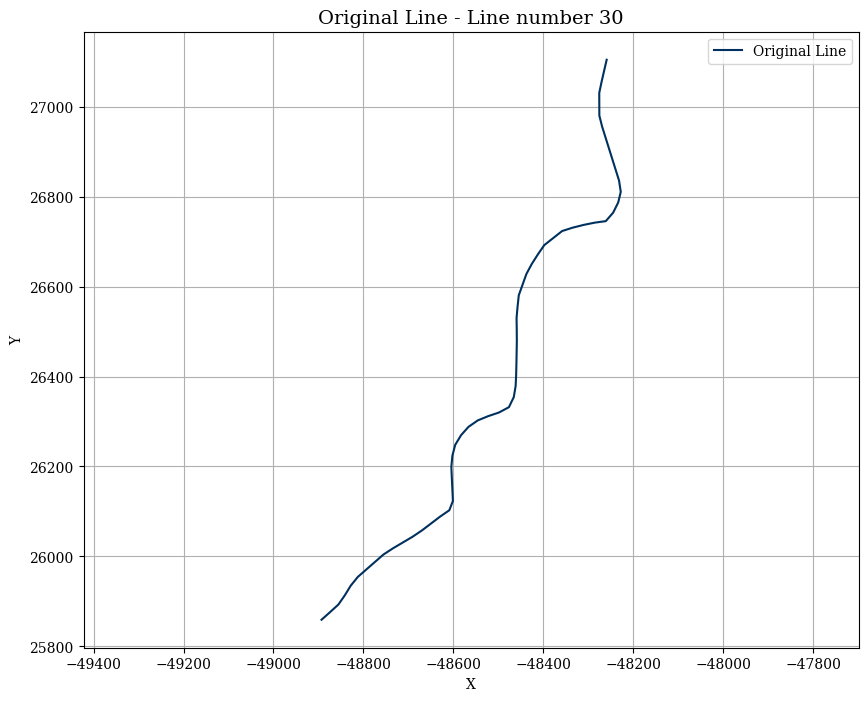

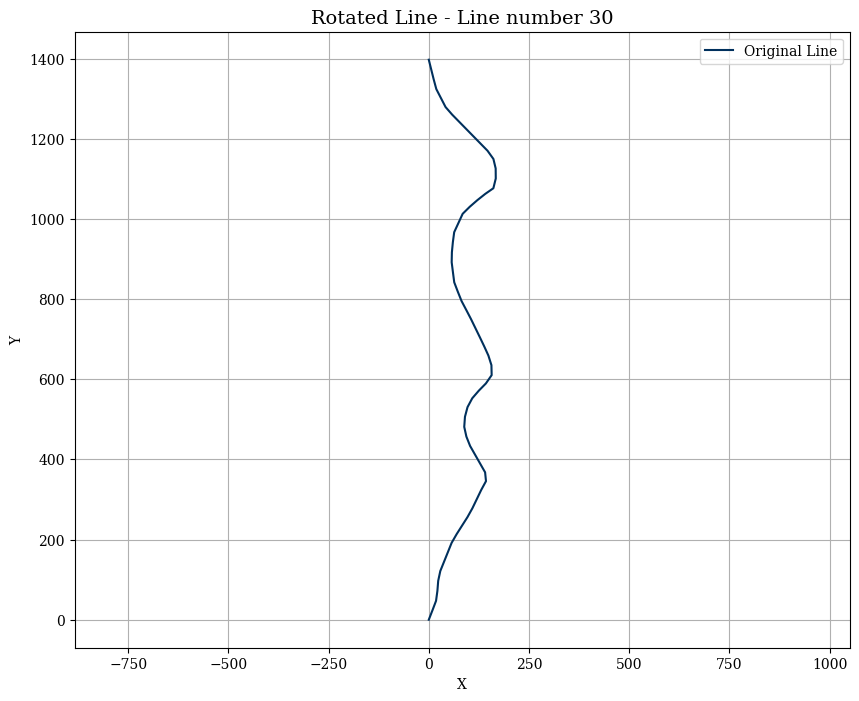

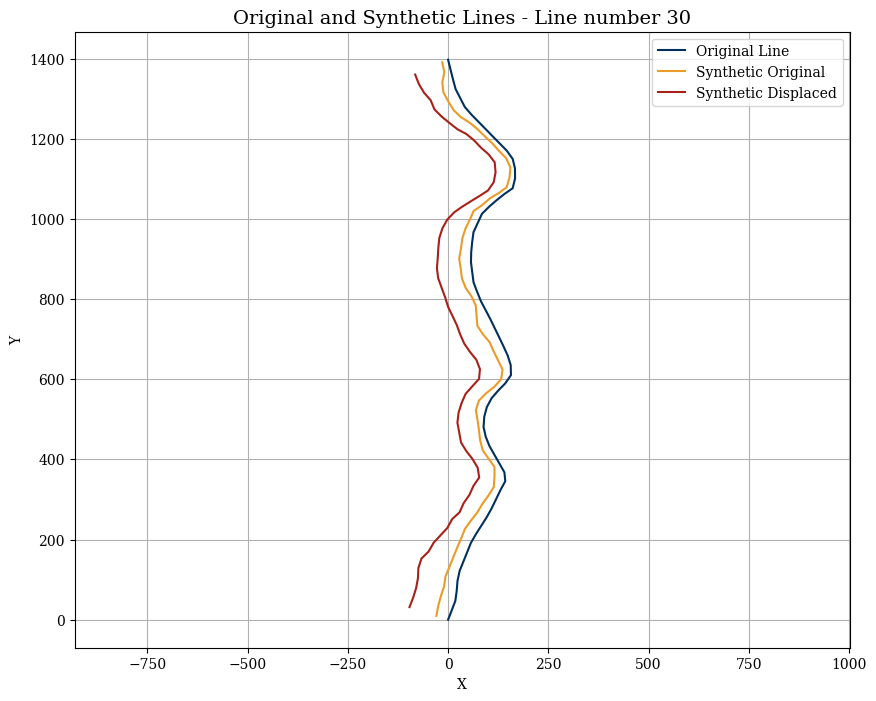

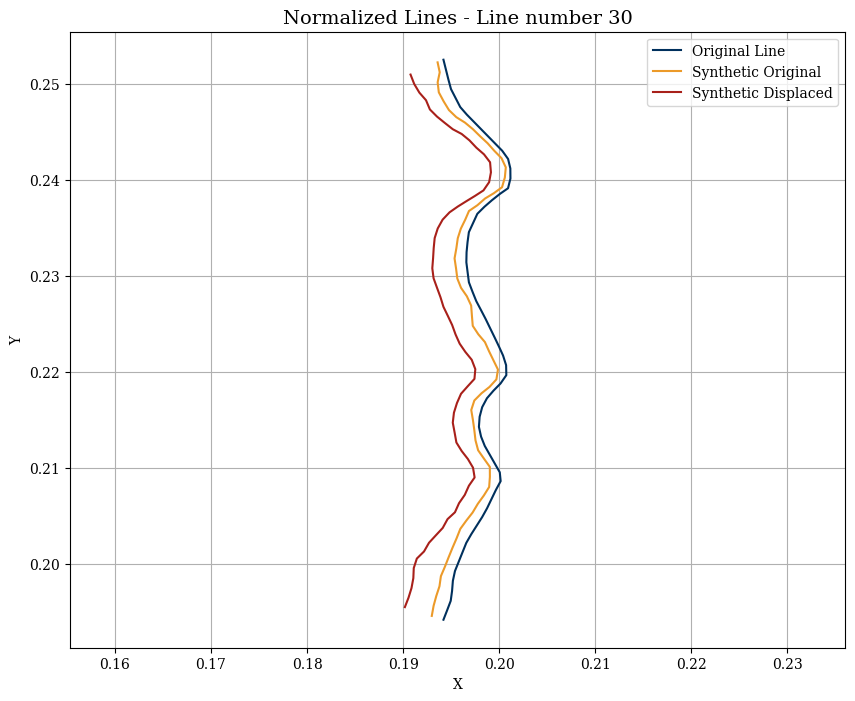

In [158]:
data_range = range(30,31)

plot_input_seq(original_interpolated_lines, data_range=data_range, description="Original Line", saving_img=True)
plot_input_seq(rotaded_lines, data_range=data_range, description="Rotated Line", saving_img=True)
plot_input_seq(rotaded_lines, rotated_lines_close, rotated_lines_far, data_range=data_range, description="Original and Synthetic Lines", saving_img=True)
plot_input_seq(normalized_original, normalized_lines_close, normalized_lines_far, data_range=data_range, description="Normalized Lines", saving_img=True)

In [10]:
# GRAPH DELAUNAY
graphs_delaunay = torch.load('../data/final_dataset/graph/graphs_delaunay_norotation_local_new.pt', weights_only=False)

In [11]:
# GRAPH SEQ
graphs_seq = torch.load('../data/final_dataset/graph/graphs_sequential_norotation_local_new.pt', weights_only=False)

In [182]:
def plot_input_graph(data, index, description='', saving_img=False):
    # Convert PyG Data -> NetworkX
    G = to_networkx(data, to_undirected=True)
    pos = {i: (float(data.x[i][1]), float(data.x[i][2])) for i in range(data.num_nodes)}

    # Node colors by line_id
    color_map = ["#143642", "#EC9A29"]
    colors = [color_map[int(data.x[i][0].item())] for i in range(data.num_nodes)]

    plt.figure(figsize=(8, 7))
    plt.title(f'Constructed Graph with {description} Edges - Line {index}', fontdict=title_font)
    plt.xlabel('X', fontdict=labels_font)
    plt.ylabel('Y', fontdict=labels_font)
    #plt.axis('equal')

    # Draw graph
    nx.draw(
        G, pos,
        node_size=5,
        node_color=colors,
        edge_color="#B3B5B6A6",
        alpha=0.8
    )

    # ---- Legend ----
    legend_elements = [
        Line2D([0], [0],marker='o',color='none',label='Line A', markerfacecolor=color_map[0], markeredgecolor='none', markersize=6),
        Line2D([0], [0],marker='o',color='none',label='Line B',markerfacecolor=color_map[1], markeredgecolor='none', markersize=6)
    ]

    plt.legend(handles=legend_elements, prop=legend_font)
    
    if saving_img:
        description = description.replace(" ", "_").lower()
        save_path = f'../data/figures/input_graph_{description}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


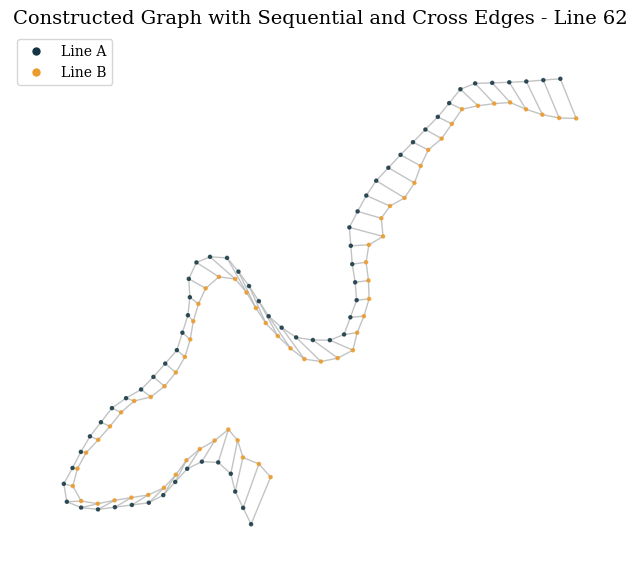

In [184]:
graph = graphs_seq
description = 'Sequential and Cross' #'Delaunay and Sequential'

for i in range(62,63):
    plot_input_graph(graph[i], i, description, saving_img=True)

## LOAD PREDICTED DATA

In [57]:
# GRAPH PREDICTIONS
path_graph_seq = '1512_1718_sequential_norotation_local_GSage_Huber_lstm_layernorm_newData_4_batches_50_epochs'
with open(f'../data/results/graph/{path_graph_seq}.pkl', 'rb') as f:
    graph_seq_pred = pickle.load(f)


path_graph_delaunay = '1512_1623_delaunay_norotation_local_GSage_Huber_layernorm_newData_4_batches_50_epochs'
with open(f'../data/results/graph/{path_graph_delaunay}.pkl', 'rb') as f:
    graph_delaunay_pred = pickle.load(f)

In [58]:
# LSTM AE 
path_lstm = '0912_1017_huber_local_finetuned_bidrectional_32_batches_50_epochs'
with open(f'../data/results/lstm_autoencoder/{path_lstm}_predictions.pkl', 'rb') as f:
    lstm_pred = pickle.load(f)

In [59]:
# SIAMESE LSTM AE PREDICTIONS
path_siamese = '16_batches_50_epochs_pretrained_local_1811_1801_siamese_lstm_autoencoder'
with open(f'../data/results/siamese_lstm_autoencoder/{path_siamese}_predictions.pkl', 'rb') as f:
    data = pickle.load(f)

siamese_pred_a = data["pred_siamese_a"]
siamese_pred_b = data["pred_siamese_b"]

## PLOTTING RESULTS

### TRAINING LOSSES

In [133]:
def plot_history_seqbased(history, epochs, description, saving_img=False):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history.keys():
        plt.plot(history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs', fontdict=labels_font)
    plt.ylabel('Loss', fontdict=labels_font)
    plt.legend(prop=legend_font)
    plt.grid(True)
    plt.title(f'LSTM Training & Validation Loss over {epochs} Epochs', fontdict=title_font)

    plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
    plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])

    if saving_img: 
        description = description.replace(" ", "_").lower()
        save_path = f'../data/figures/train_val_loss_{description}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

dict_keys(['accuracy', 'loss', 'mae', 'mse', 'val_accuracy', 'val_loss', 'val_mae', 'val_mse'])


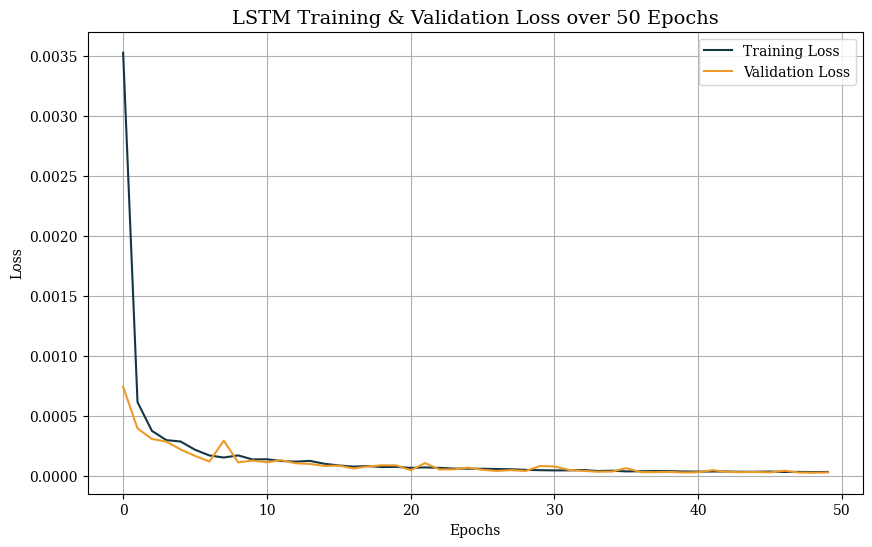

In [134]:
# LSTM AE 
history = np.load(f"../checkpoints/autoencoder/history/{path_lstm}.npy", allow_pickle=True).item()
print(history.keys())
epochs = len(history['accuracy'])
description='lstm_ae'

plot_history_seqbased(history, epochs, description, False)

In [ ]:
# SIAMESE LSTM AE 
# history = np.load('../checkpoints/siamese/history/siamese_history.npy', allow_pickle=True).item()
#print(history.keys())
# epochs = len(history['accuracy'])
# description='siamese_lstm_ae'

# plot_history_seqbased(history, epochs, description, False)

In [165]:
def plot_history_graphbased(train_losses, val_losses, description, saving_img=False):
    epochs = len(train_losses)

    plt.figure(figsize=(10,6))
    plt.plot(range(0, epochs + 0), train_losses, label='Train Loss', color='#143642') #range(1, epochs+1)
    plt.plot(range(0, epochs + 0), val_losses, label='Validation Loss', color='#EC9A29') #range(1, epochs+1)
    plt.xlabel('Epoch', fontdict=labels_font)
    plt.ylabel('Loss', fontdict=labels_font)
    plt.title(f'{description} Training & Validation Loss {epochs} over Epochs', fontdict=title_font)
    plt.legend(prop=legend_font)
    plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
    plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])
    plt.grid(True)

    if saving_img: 
        description = description.replace(" ", "_").lower()
        save_path = f'../data/figures/results_train_val_loss_{description}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

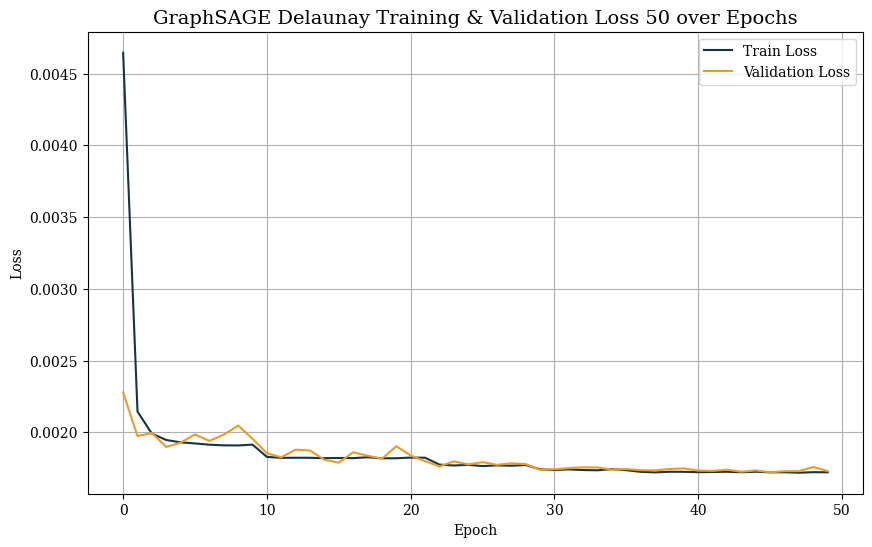

In [166]:
# GraphSAGE Delaunay
train_losses = np.load(f'../checkpoints/graph/history/{path_graph_delaunay}_train_loss.npy')
val_losses = np.load(f'../checkpoints/graph/history/{path_graph_delaunay}_val_loss.npy')
description='GraphSAGE Delaunay'

plot_history_graphbased(train_losses, val_losses, description, True)

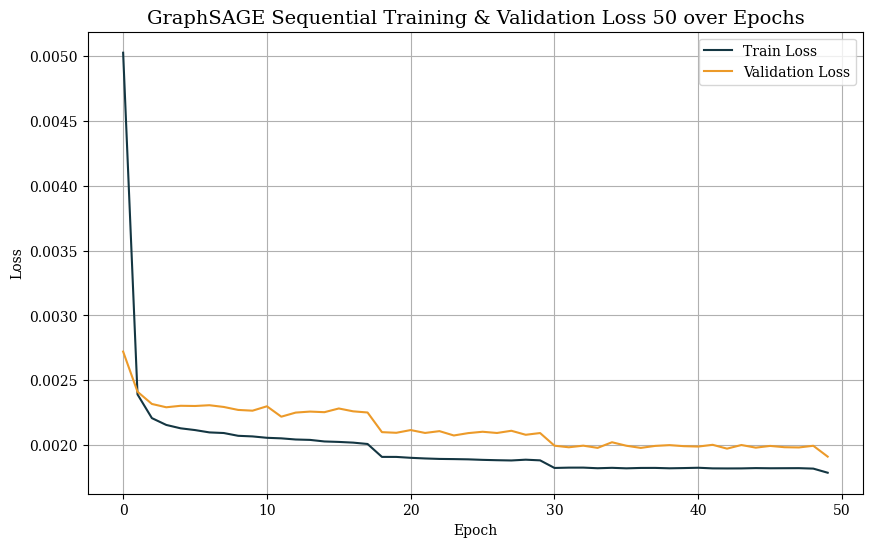

In [167]:
# GraphSage SEQ
train_losses = np.load(f'../checkpoints/graph/history/{path_graph_seq}_train_loss.npy')
val_losses = np.load(f'../checkpoints/graph/history/{path_graph_seq}_val_loss.npy')
description='GraphSAGE Sequential'

plot_history_graphbased(train_losses, val_losses, description, True)

## PLOTTING PREDICTED LINES

#### PURE LSTM AE

In [168]:
def plot_lstm_ae_prediction(data_test, data_pred, data_range, description, saving_img=False):

    for i in data_range:
        plt.figure(figsize=(6, 10))
        plt.plot(data_test[i,:,0], data_test[i,:,1], color='#143642', linestyle='--',label='Original')
        plt.plot(data_pred[i,:,0], data_pred[i,:,1], color='#EC9A29',label='Reconstructed')
        plt.legend(prop=legend_font)
        plt.grid(True)
        plt.xlabel('X', fontdict=labels_font)
        plt.ylabel('Y', fontdict=labels_font)
        plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
        plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])

        #plt.axis('equal')
        plt.title(f'LSTM AE - Line {i}', fontdict=title_font)

        if saving_img:
            description = description.replace(" ", "_").lower()
            save_path = f'../data/figures/results_{description}_pred_line_{i}.png'
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

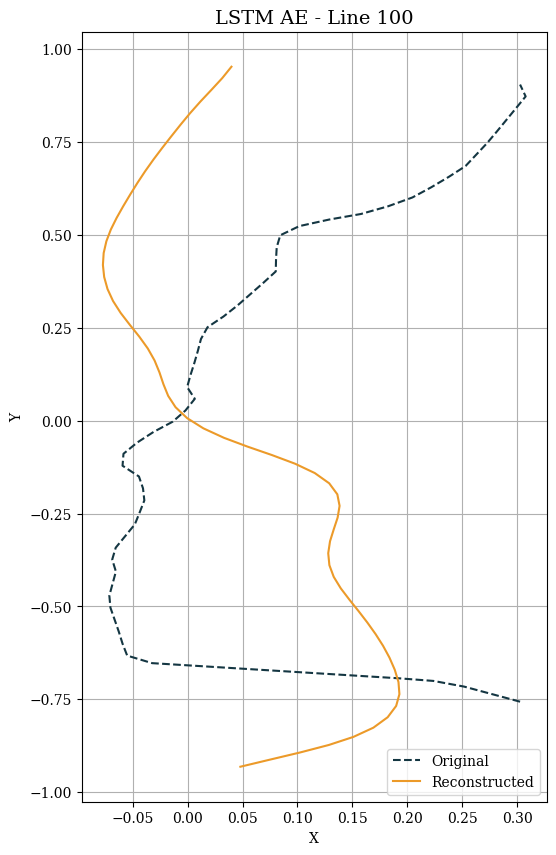

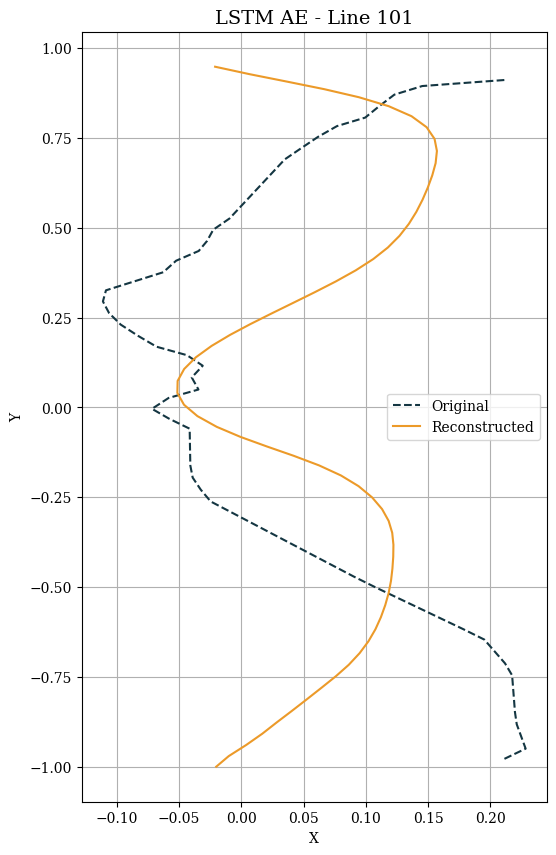

In [169]:
data_range = range(100,102)
description = 'lstm_ae'
plot_lstm_ae_prediction(lstm_ae_test, lstm_pred, data_range, description, saving_img=False)

#### SIAMESE LSTM AE

In [171]:
def plot_siamese_prediction(data_a_test, data_a_pred, data_b_test, data_b_pred, data_range=range(1,10), description='', saving_img=False):

    for j in data_range:
        plt.figure(figsize=(6, 10))
        
        plt.plot(data_a_test[j,:, 0], data_a_test[j,:, 1], color='#A8201A', label='Original A', linestyle='--')
        plt.plot(data_b_test[j,:, 0], data_b_test[j,:, 1], color='#143642', label='Original B', linestyle='--')
        plt.plot(data_a_pred[j,:, 0], data_a_pred[j,:, 1], color='#EC9A29', label='Prediction A')
        plt.plot(data_b_pred[j,:, 0], data_b_pred[j,:, 1], color='#286981', label='Prediction B')

        plt.title(f'Siamese LSTM AE - Line {j}', fontdict=title_font)
        plt.xlabel('X', fontdict=labels_font)
        plt.ylabel('Y', fontdict=labels_font)

        plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
        plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])

        plt.legend(prop=legend_font)
        plt.grid(True)
        #plt.axis('equal')
        
        if saving_img:
            description = description.replace(" ", "_").lower()
            save_path = f'../data/figures/results_{description}_pred_line_{j}.png'
            plt.savefig(save_path, dpi=300, bbox_inches='tight') 
        plt.show()

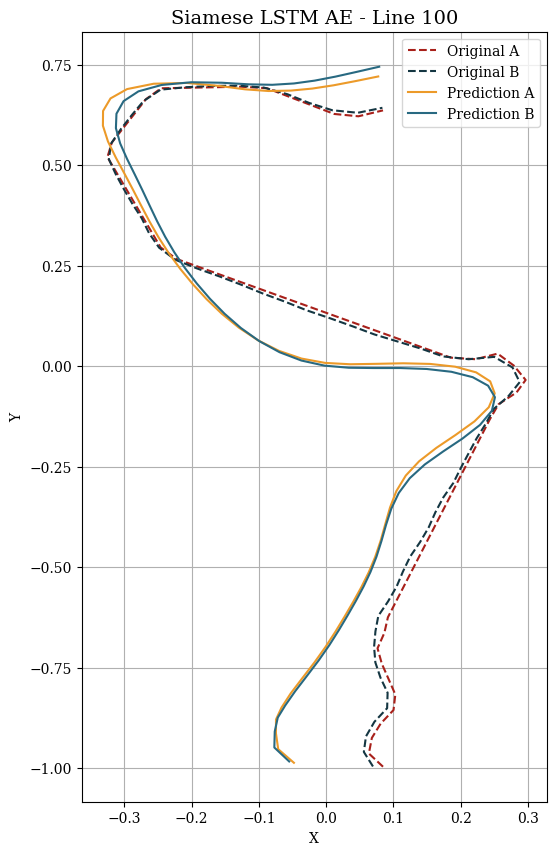

In [172]:
data_range = range(100,101)
description = 'siamese'
plot_siamese_prediction(lines_a_noisy_test, siamese_pred_a, lines_b_noisy_test, siamese_pred_b, data_range, description, saving_img=False)

#### GRAPHS

In [148]:
def plot_predictions(pred_entry, description, graph_id, saving_img=False):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    orig_a_coords = coords[line_id == 0]
    orig_b_coords = coords[line_id == 1]
    true_b = orig_b_coords + true_shift[line_id == 1]
    pred_b = orig_b_coords + pred_shift[line_id == 1]

    plt.figure(figsize=(10,6))

    plt.plot(orig_a_coords[:,0], orig_a_coords[:,1],'-o', color="#143642", markersize=1, label="Original A")
    plt.plot(orig_b_coords[:,0], orig_b_coords[:,1],'-o', color="#EC9A29", markersize=1, label="Original B")
    #plt.plot(true_b[:,0], true_b[:,1], '-o', color="#0F8B8D", markersize=2, label="Target B")

    # Predicted B
    plt.plot(pred_b[:,0], pred_b[:,1],'-o', color="#A8201A", markersize=2, label="Predicted B")

    # Shift arrows
    for i in range(len(orig_b_coords)):
        plt.arrow(
            orig_b_coords[i,0], orig_b_coords[i,1],
            pred_b[i,0] - orig_b_coords[i,0],
            pred_b[i,1] - orig_b_coords[i,1],
            head_width=0.002, head_length=0.004,
            fc="#A8201A", ec="#A8201A", alpha=0.2
        )

    plt.legend(prop=legend_font)
    plt.title(f"{description} Prediction vs Ground Truth - Graph {graph_id}", fontdict=title_font)
    plt.xlabel("X", fontdict=labels_font)
    plt.ylabel("Y", fontdict=labels_font)
    plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
    plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])

    plt.axis("equal")

    if saving_img:
        description = description.replace(" ", "_").lower()
        save_path = f'../data/figures/results_{description}_pred_line_{graph_id}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight') 

    plt.show()

#### GRAPH SAGE SEQ

In [149]:
# type(graph_seq_pred[1])
# graph_seq_pred[1].keys()

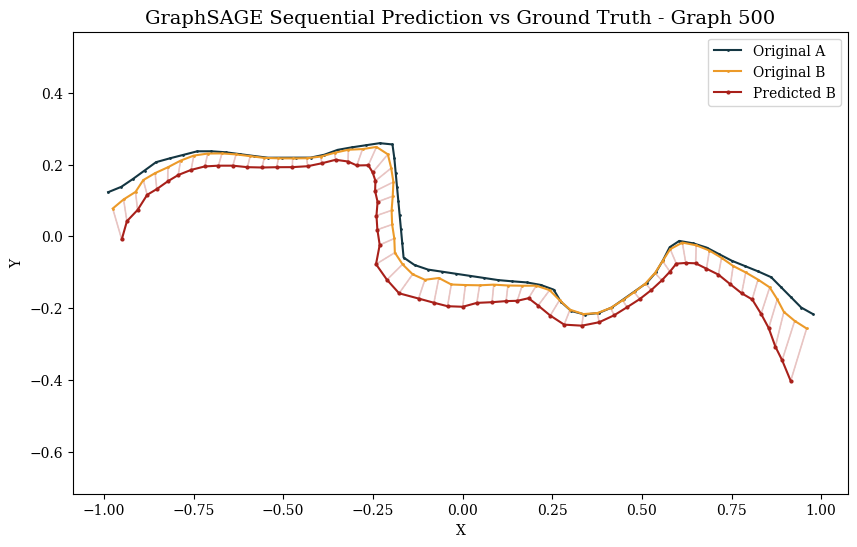

In [150]:
description = 'GraphSAGE Sequential'
for graph_id in range(500,501):
    plot_predictions(graph_seq_pred[graph_id], description, graph_id, saving_img=False)


#### GRAPH SAGE DELAUNAY

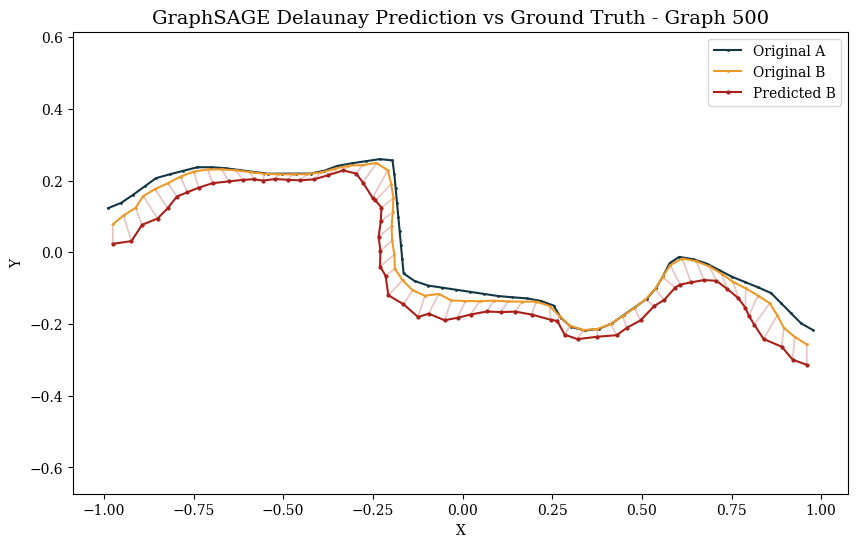

In [151]:
description = 'GraphSAGE Delaunay'
for graph_id in range(500,501):
    plot_predictions(graph_delaunay_pred[graph_id], description, graph_id, saving_img=False)

## EVALUATION METRICS

In [ ]:
def frechet_distance(P, Q):
    """
    Compute discrete Fréchet distance between two 2D polylines P and Q.
    P, Q: arrays of shape (N, 2)
    """
    n, m = len(P), len(Q)
    ca = -np.ones((n, m))

    def dist(p, q):
        return np.linalg.norm(p - q)

    def recurse(i, j):
        if ca[i, j] > -1:
            return ca[i, j]
        elif i == 0 and j == 0:
            ca[i, j] = dist(P[0], Q[0])
        elif i > 0 and j == 0:
            ca[i, j] = max(recurse(i-1, 0), dist(P[i], Q[0]))
        elif i == 0 and j > 0:
            ca[i, j] = max(recurse(0, j-1), dist(P[0], Q[j]))
        elif i > 0 and j > 0:
            ca[i, j] = max(
                min(
                    recurse(i-1, j),
                    recurse(i, j-1),
                    recurse(i-1, j-1)
                ),
                dist(P[i], Q[j])
            )
        else:
            ca[i, j] = float("inf")
        return ca[i, j]

    return recurse(n-1, m-1)

def sample_frechet(pred_entry):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    syn1_coords = coords[line_id == 1]
    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    return frechet_distance(true_s2, pred_s2)

In [ ]:
def hausdorff_distance(P, Q):
    d1 = directed_hausdorff(P, Q)[0]
    d2 = directed_hausdorff(Q, P)[0]
    return max(d1, d2)

def sample_hausdorff(pred_entry):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    syn1_coords = coords[line_id == 1]
    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    return hausdorff_distance(true_s2, pred_s2)

In [ ]:
def dtw_distance(P, Q):
    distance, _ = fastdtw(P, Q, dist=euclidean)
    return distance

def sample_dtw(pred_entry):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    syn1_coords = coords[line_id == 1]
    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    return dtw_distance(true_s2, pred_s2)

In [ ]:
def dtw_similarity(P, Q, radius=5):
    """
    DTW similarity between two 2D curves.
    Returns value in (0, 1], higher = more similar
    """
    distance, path = fastdtw(P, Q, dist=euclidean, radius=radius)
    normalized_dist = distance / len(path)
    similarity = 1.0 / (1.0 + normalized_dist)
    return similarity

def sample_dtw_similarity(pred_entry):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    syn1_coords = coords[line_id == 1]
    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    return dtw_similarity(true_s2, pred_s2)

In [ ]:
def area_between_curves(P, Q):
    P_sorted = P[np.argsort(P[:, 0])]
    Q_sorted = Q[np.argsort(Q[:, 0])]

    common_x = np.linspace(
        max(P_sorted[0, 0], Q_sorted[0, 0]),
        min(P_sorted[-1, 0], Q_sorted[-1, 0]),
        num=100
    )
    P_interp_y = np.interp(common_x, P_sorted[:, 0], P_sorted[:, 1])
    Q_interp_y = np.interp(common_x, Q_sorted[:, 0], Q_sorted[:, 1])

    area = np.trapz(np.abs(P_interp_y - Q_interp_y), x=common_x)
    return area

def sample_area(pred_entry):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    syn1_coords = coords[line_id == 1]
    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    return area_between_curves(true_s2, pred_s2)

In [ ]:
metric_labels = {
    "sample_hausdorff": "Hausdorff Distance",
    "sample_frechet": "Fréchet Distance",
    "sample_dtw": "Dynamic Time Warping Distance",
    "sample_areasample_area": "Area Difference",
    "sample_dtw_similarity": "DTW Similarity"
}

def plot_metric_histogram(all_predictions, metric_func, bins=50, title=None, saving_img=False):
    values = [metric_func(entry) for entry in all_predictions]
    mean_val = np.mean(values)
    median_val = np.median(values)
    
    plt.figure(figsize=(8,5))
    plt.hist(values, bins=bins, edgecolor='#143642',linewidth=0.75, color='white')

    plt.axvline(mean_val, color='#A8201A', linestyle='--', label=f'Mean: {mean_val:.2f}', linewidth=0.95)
    plt.axvline(median_val, color='#EC9A29', linestyle='--', label=f'Median: {median_val:.2f}', linewidth=0.95)

    plt.legend(prop=legend_font)
    xlabel = metric_labels.get(metric_func.__name__, metric_func.__name__.replace("_", " ").title())
    plt.xlabel(xlabel, fontdict=labels_font)
    plt.ylabel("Number of Lines", fontdict=labels_font)
    plt.title(title or f"Histogram of {xlabel}s", fontdict=title_font)

    plt.xticks(fontsize=tick_font['size'], family=tick_font['family'])
    plt.yticks(fontsize=tick_font['size'], family=tick_font['family'])

    #plt.grid(alpha=0.3)
    if saving_img:
        save_path = f'../data/figures/graph_seq_pred_{metric_func.__name__}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight') 

    plt.show()

In [ ]:
#plot_metric_histogram(graph_seq_pred, sample_hausdorff, saving_img=True)
plot_metric_histogram(graph_seq_pred, sample_frechet, saving_img=True)
#plot_metric_histogram(graph_seq_pred, sample_dtw)
#plot_metric_histogram(graph_seq_pred, sample_area)
#plot_metric_histogram(graph_seq_pred, sample_dtw_similarity)


### MSE

In [ ]:
def sample_mse(pred_entry):
    true = pred_entry["true_shift"][pred_entry["line_id"] == 1]
    pred = pred_entry["pred_shift"][pred_entry["line_id"] == 1]
    return ((true - pred) ** 2).mean()


In [ ]:
def plot_mse_histogram(all_predictions, bins=50):
    mses = [sample_mse(entry) for entry in all_predictions]
    
    plt.figure(figsize=(8,6))
    plt.hist(mses, bins=bins, color='#143642')
    plt.xlabel("MSE")
    plt.ylabel("Count")
    plt.title("Histogram of MSE for All Test Samples")
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
plot_mse_histogram(graph_seq_pred)

In [ ]:
def plot_error(pred_entry, description, graph_id):
    coords = pred_entry["coords"]
    true_shift = pred_entry["true_shift"]
    pred_shift = pred_entry["pred_shift"]
    line_id = pred_entry["line_id"]

    syn1_coords = coords[line_id == 1]
    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    # Per-node Euclidean error
    error = np.linalg.norm(pred_s2 - true_s2, axis=1)

    plt.figure(figsize=(10,6))
    plt.scatter(syn1_coords[:,0], syn1_coords[:,1], c=error, cmap="viridis", s=20)
    plt.colorbar(label="Euclidean Error")
    plt.title(f"Prediction Error per Node - Graph {graph_id}")
    plt.axis("equal")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


In [ ]:
index = 500
plot_predictions(graph_seq_pred[index], '', index, False)
plot_error(graph_seq_pred[index], '', index)

### RENAMING FILE PATHS

In [ ]:
import os
import re

directory = "../checkpoints/graph/history"  

if not os.path.isdir(directory):
    print(f"Error: The directory {directory} does not exist.")
else:
    for fname in os.listdir(directory):
        if not fname.endswith(".npy"):
            continue

        match = re.search(r"(train_loss|val_loss)", fname)
        if not match:
            continue

        loss_part = match.group(1)
        new_name = re.sub(rf"_{loss_part}", "", fname)
        new_name = new_name.replace(".npy", f"_{loss_part}.npy")

        if new_name != fname:
            old_path = os.path.join(directory, fname)
            new_path = os.path.join(directory, new_name)

            if not os.path.exists(old_path):
                print(f"Error: {old_path} does not exist.")
            else:
                print(f"Renaming: {old_path} → {new_path}")
                try:
                    os.rename(old_path, new_path)
                except FileNotFoundError as e:
                    print(f"Error renaming {old_path} → {new_path}: {e}")
                except Exception as e:
                    print(f"Unexpected error while renaming {old_path}: {e}")